### Convolutional neural network (CNN): Use MNIST Fashion Dataset and create a classifier to classify fashion clothing into categories.

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# Load the Fashion MNIST dataset
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
# Class names for the 10 categories
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Normalize pixel values from [0, 255] to [0.0, 1.0]
train_images = train_images / 255.0
test_images = test_images / 255.0
print(f"Train images shape : {train_images.shape}") # (60000, 28, 28)
print(f"Test images shape : {test_images.shape}") # (10000, 28, 28)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train images shape : (60000, 28, 28)
Test images shape : (10000, 28, 28)


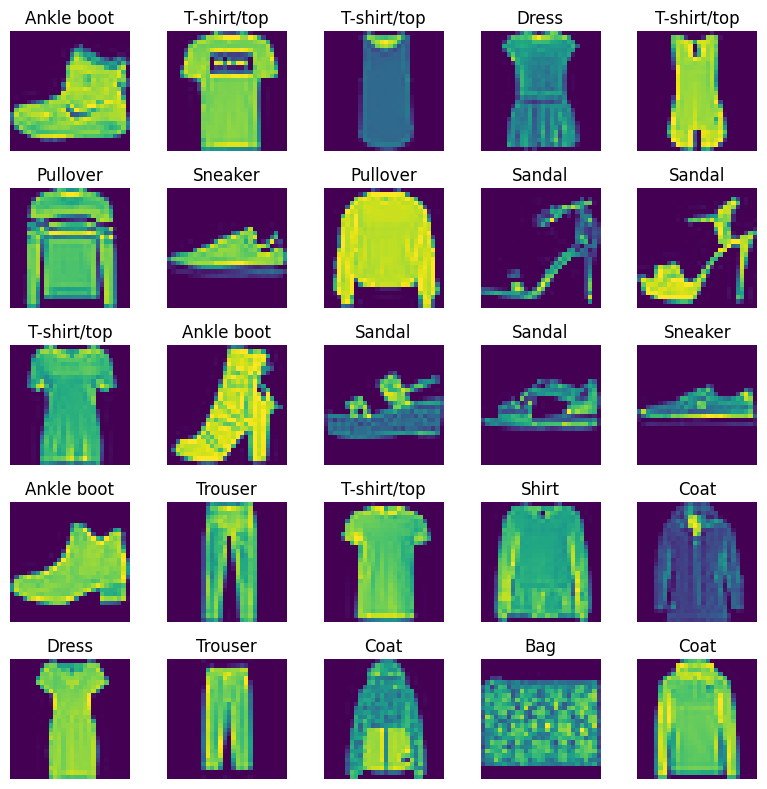

In [10]:
# Show first 9 training images with their labels
plt.figure(figsize=(8, 8))
for i in range(25):
  plt.subplot(5, 5, i + 1)
  plt.imshow(train_images[i], cmap='gray')
  plt.title(class_names[train_labels[i]])
  plt.axis('off')
plt.tight_layout()
plt.show()

In [4]:
# CNN expects shape (height, width, channels) — reshape to add channel dim
train_images = train_images.reshape(-1, 28, 28, 1)
test_images = test_images.reshape(-1, 28, 28, 1)
# Define the model (following lab manual architecture)
model = keras.Sequential([
# Convolutional layer: 64 filters, 3x3 kernel, ReLU activation
keras.layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
# Max pooling layer: reduces spatial dimensions by 2x
keras.layers.MaxPooling2D(2, 2),
# Flatten: convert 2D feature maps to 1D vector
keras.layers.Flatten(),
# Fully connected layer with 128 neurons
keras.layers.Dense(128, activation='relu'),
# Output layer: 10 neurons (one per class), softmax for probabilities
keras.layers.Dense(10, activation='softmax')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,384,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,386,506 (5.29 MB)

 Trainable params: 1,386,506 (5.29 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Compile with adam optimizer and sparse categorical cross-entropy loss
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)
print("Model compiled successfully.")

Model compiled successfully.


In [6]:
# Train the model for 10 epochs
# Early Stopping callback
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',   # watches validation loss
    patience=2,           # wait 2 epochs before stopping
)

history = model.fit(
train_images, train_labels,
epochs=10,
validation_split=0.1, # 10% of training data used for validation
callbacks=[early_stop]
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.8614 - loss: 0.3905 - val_accuracy: 0.8822 - val_loss: 0.3181
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9045 - loss: 0.2633 - val_accuracy: 0.9055 - val_loss: 0.2584
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9211 - loss: 0.2156 - val_accuracy: 0.9060 - val_loss: 0.2588
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9338 - loss: 0.1817 - val_accuracy: 0.9035 - val_loss: 0.2802


In [7]:
# Evaluate on the test set
test_loss, test_acc = model.evaluate(test_images, test_labels)
print('Test accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8993 - loss: 0.2869
Test accuracy: 0.8992999792098999


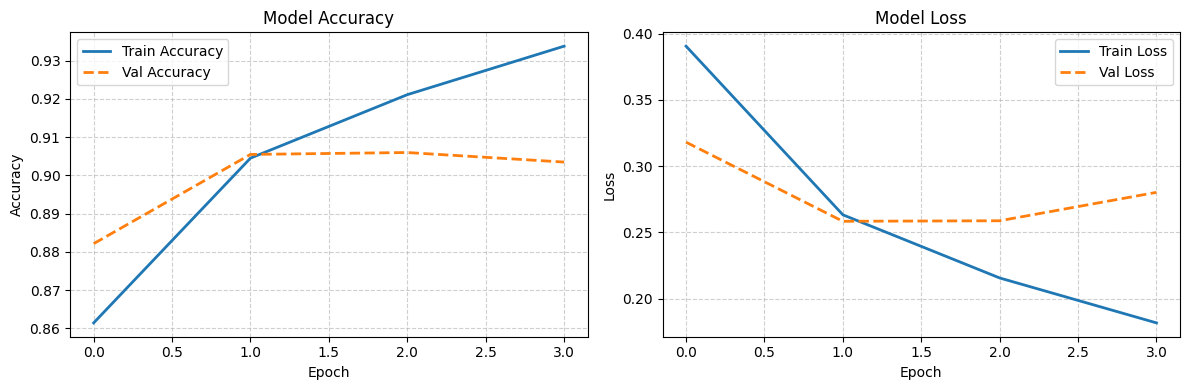

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Accuracy plot
axes[0].plot(history.history['accuracy'],

linestyle='-', linewidth=2, label='Train Accuracy')

axes[0].plot(history.history['val_accuracy'],

linestyle='--', linewidth=2, label='Val Accuracy')

axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(frameon=True)
axes[0].grid(True, linestyle='--', alpha=0.6)
# Loss plot
axes[1].plot(history.history['loss'],

linestyle='-', linewidth=2, label='Train Loss')

axes[1].plot(history.history['val_loss'],

linestyle='--', linewidth=2, label='Val Loss')

axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(frameon=True)
axes[1].grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


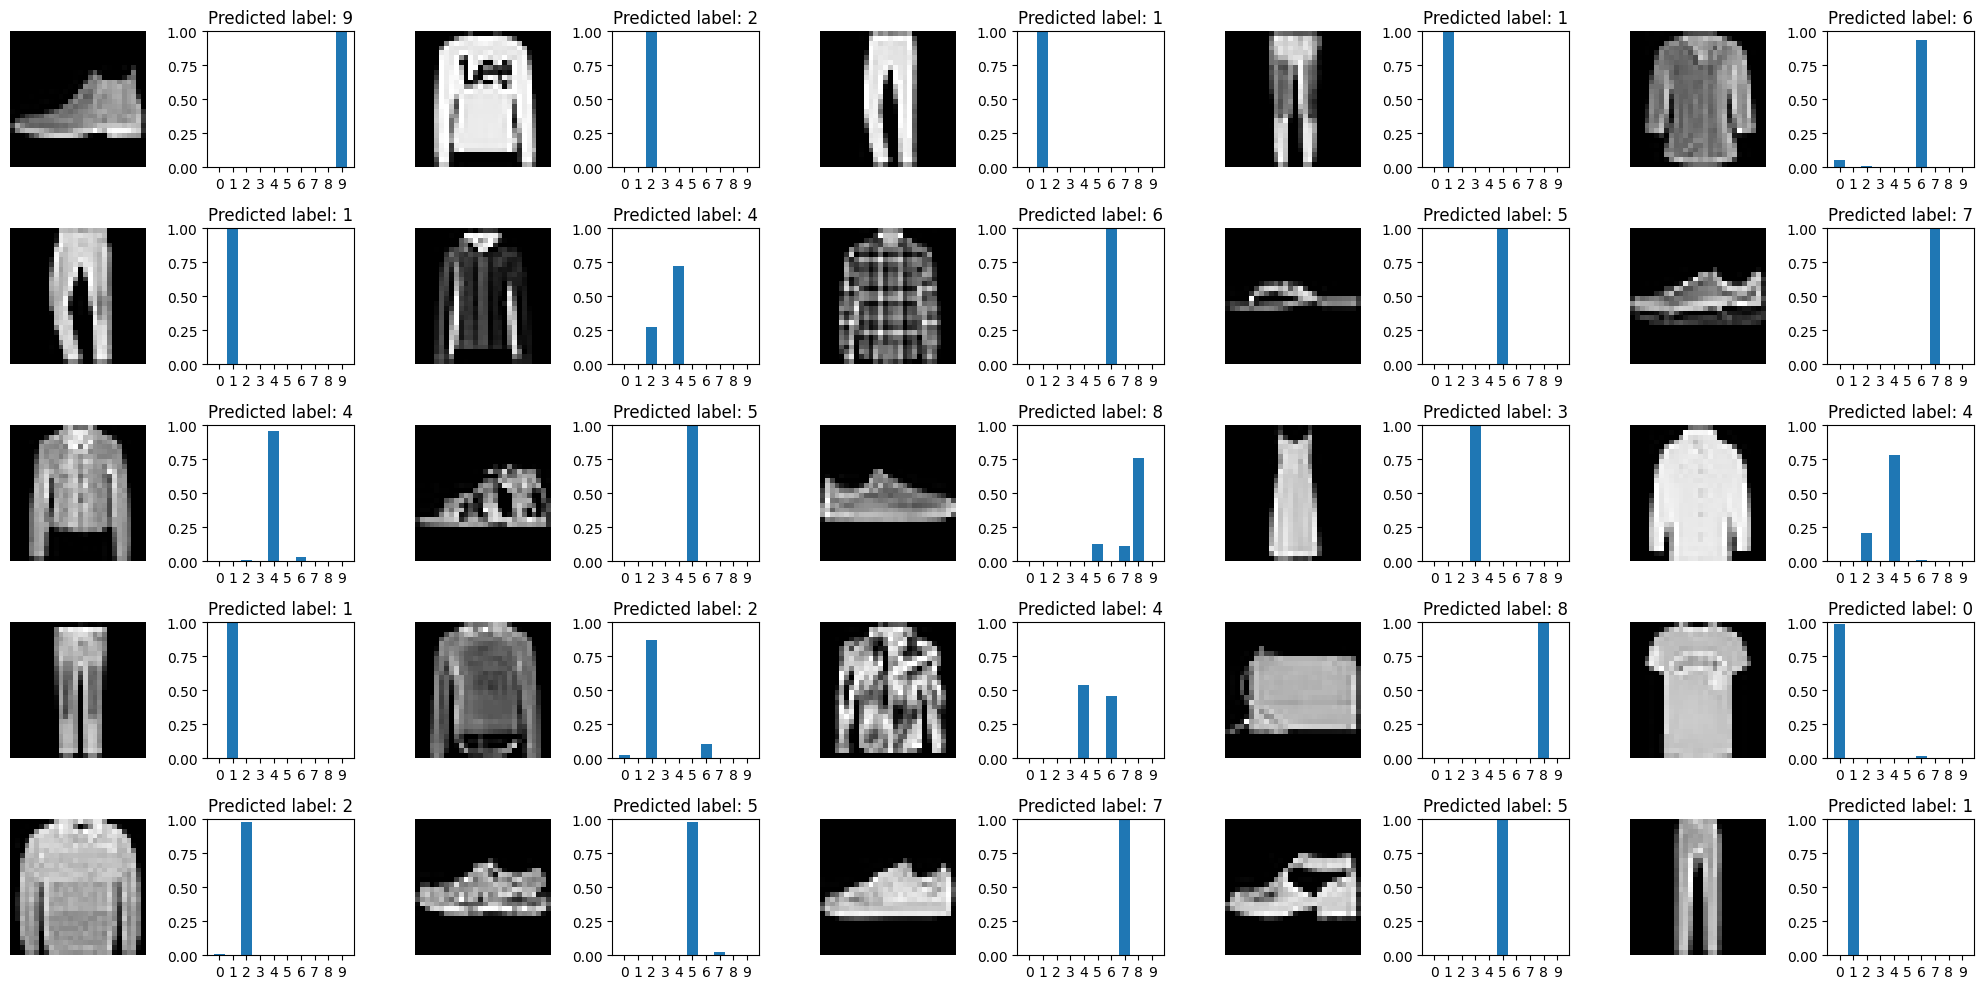

In [9]:
# Make predictions on test set
predictions = model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)
# Show sample images and their predicted labels (matching lab manual output)
num_rows = 5
num_cols = 5
num_images = num_rows * num_cols
plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))
for i in range(num_images):
  # Left subplot: image
  plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
  plt.imshow(test_images[i], cmap='gray')
  plt.axis('off')
  # Right subplot: prediction bar chart
  plt.subplot(num_rows, 2 * num_cols, 2 * i + 2)
  plt.bar(range(10), predictions[i])
  plt.xticks(range(10))
  plt.ylim([0, 1])
  plt.title(f"Predicted label: {predicted_labels[i]}")
plt.tight_layout()
plt.show()